### 차트 작성 시 한글 깨짐 방지를 위한 koreanize-matplotlib 설치

In [ ]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 60.8 MB/s eta 0:00:00


### 라이브러리 import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.datasets import load_diabetes
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

### 1단계: 데이터 이해 및 불러오기 (Load Data)

In [2]:
pima_columns = ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree_function', 'age', 'outcome']
pima_data_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
df = pd.read_csv(pima_data_url, names=pima_columns)

In [3]:
df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pregnancies                 768 non-null    int64  
 1   glucose                     768 non-null    int64  
 2   blood_pressure              768 non-null    int64  
 3   skin_thickness              768 non-null    int64  
 4   insulin                     768 non-null    int64  
 5   bmi                         768 non-null    float64
 6   diabetes_pedigree_function  768 non-null    float64
 7   age                         768 non-null    int64  
 8   outcome                     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### 2단계: 데이터 품질 검증 (Data Quality Check)

In [ ]:
# 1. 결측치(NaN) 확인
missing_values = df.isnull().sum()
display(missing_values)

,0
pregnancies,0
glucose,0
blood_pressure,0
skin_thickness,0
insulin,0
bmi,0
diabetes_pedigree_function,0
age,0
outcome,0


In [ ]:
# 2. 숨겨진 결측치 (0값) 탐색
zero_cols = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']

for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    print(f" - {col}: {zero_count}개 ({zero_count/len(df)*100:.2f}%)")

 - glucose: 5개 (0.65%)
 - blood_pressure: 35개 (4.56%)
 - skin_thickness: 227개 (29.56%)
 - insulin: 374개 (48.70%)
 - bmi: 11개 (1.43%)


### 3단계: 기술 통계 및 분포 분석 (Descriptive Statistics)

In [ ]:
# 수치형 데이터 요약
df.describe()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### 전체 변수 히스토그램 시각화

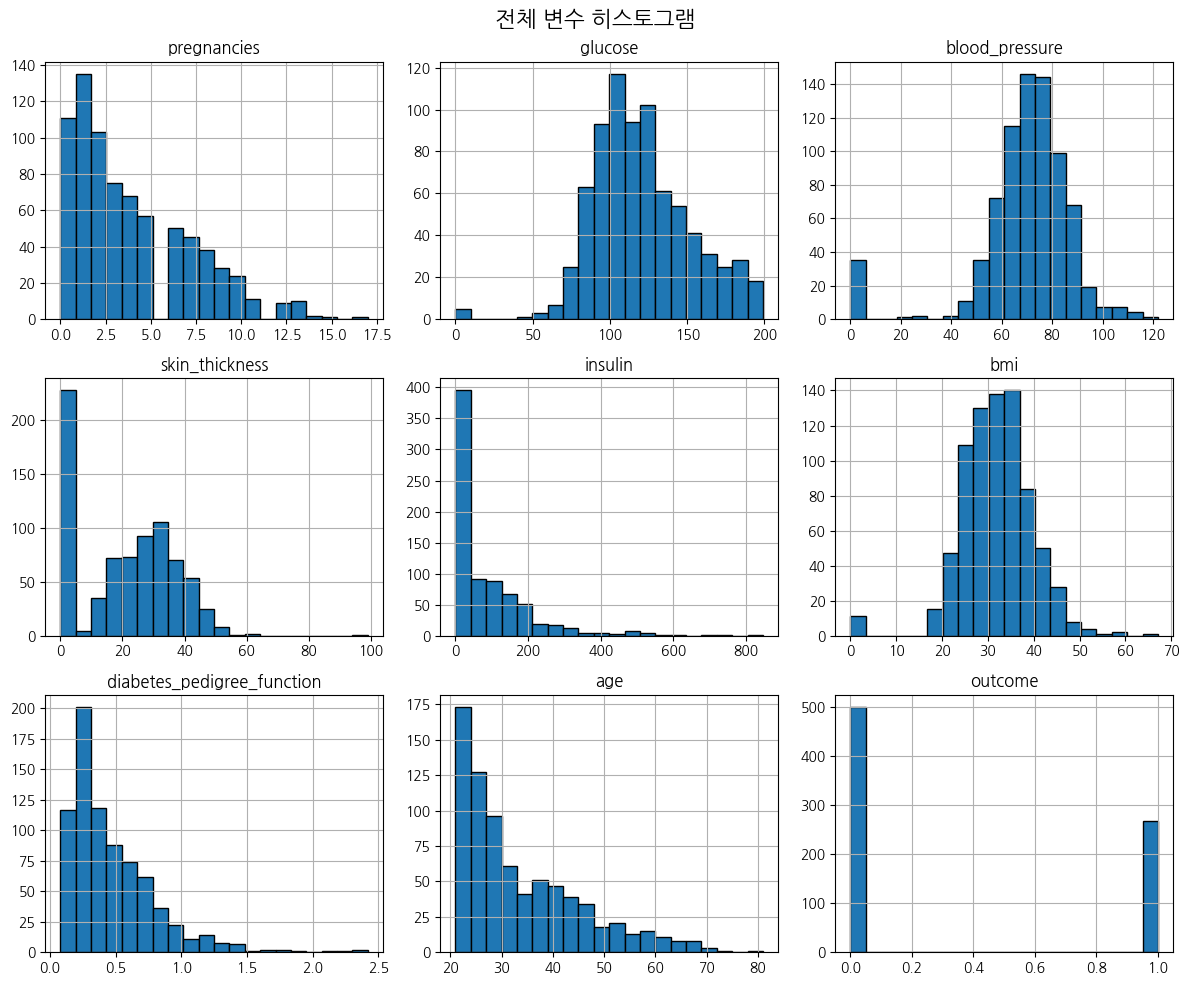

In [6]:
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("전체 변수 히스토그램", fontsize=16)
plt.tight_layout()
plt.show()

### 3-1단계: 타겟 변수 'outcome' 심층 분석

In [7]:
# 빈도 및 비율 확인
outcome_counts = df['outcome'].value_counts()
outcome_ratios = df['outcome'].value_counts(normalize=True)

print(f"0 (정상): {outcome_counts[0]}명 ({outcome_ratios[0]*100:.1f}%)")
print(f"1 (당뇨): {outcome_counts[1]}명 ({outcome_ratios[1]*100:.1f}%)")

0 (정상): 500명 (65.1%)
1 (당뇨): 268명 (34.9%)


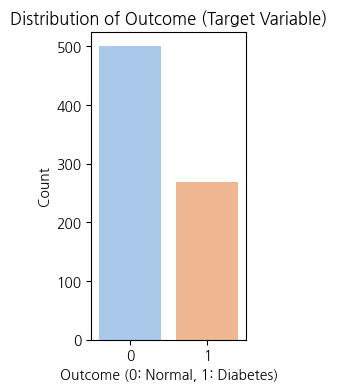

In [ ]:
# 시각화 (Count Plot)
plt.figure(figsize=(2, 4))
sns.countplot(x='outcome', data=df, palette='pastel')
plt.title('Distribution of Outcome (Target Variable)')
plt.xlabel('Outcome (0: Normal, 1: Diabetes)')
plt.ylabel('Count')
plt.show()

### 4단계: 이상치 탐지 (Outlier Detection - IQR)

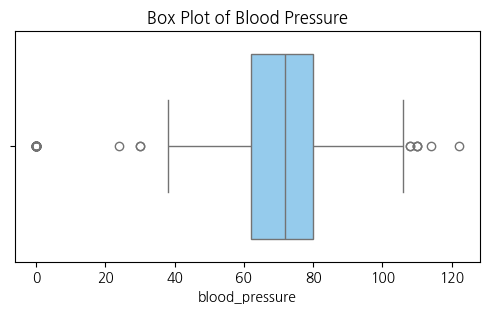

In [ ]:
# Box Plot 시각화
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['blood_pressure'], color='lightskyblue')
plt.title('Box Plot of Blood Pressure')
plt.show()

In [ ]:
# IQR 계산 로직
Q1 = df['blood_pressure'].quantile(0.25)
Q3 = df['blood_pressure'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"IQR: {IQR}")
print(f"이상치 하한 경계: {lower_bound}")
print(f"이상치 상한 경계: {upper_bound}")

IQR: 18.0
이상치 하한 경계: 35.0
이상치 상한 경계: 107.0


### 5단계: 변수 간 관계 분석 (Correlation Analysis)

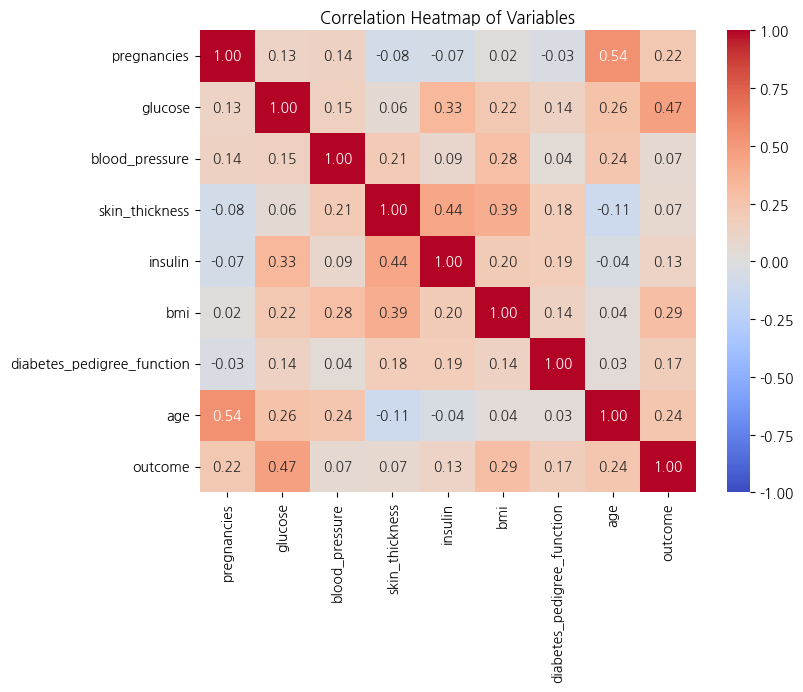

In [ ]:
# 상관계수 행렬 계산
corr_matrix = df.corr()

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Variables')
plt.show()

### 5-1단계: 심층 분석 - glucose vs outcome (KDE Plot)

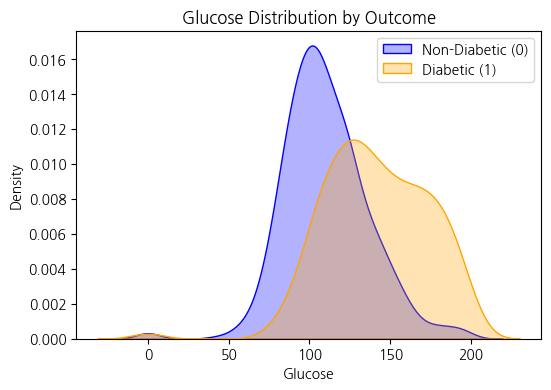

In [ ]:
plt.figure(figsize=(6, 4))
# 변경된 컬럼명 glucose, outcome 적용
sns.kdeplot(data=df[df['outcome'] == 0]['glucose'], label='Non-Diabetic (0)', fill=True, color='blue', alpha=0.3)
sns.kdeplot(data=df[df['outcome'] == 1]['glucose'], label='Diabetic (1)', fill=True, color='orange', alpha=0.3)

plt.title('Glucose Distribution by Outcome')
plt.xlabel('Glucose')
plt.ylabel('Density')
plt.legend()
plt.show()

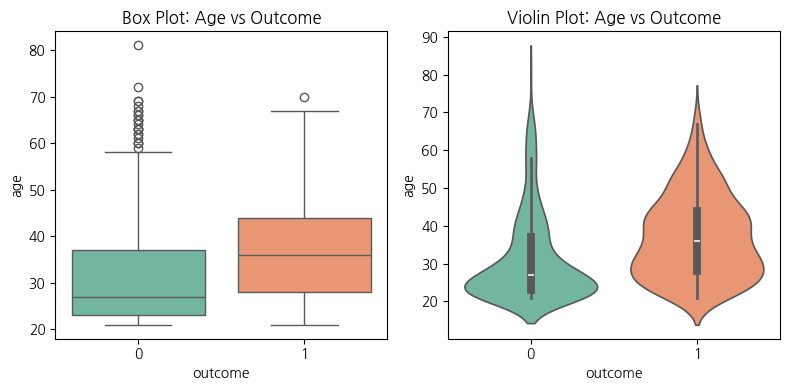

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Box Plot
sns.boxplot(x='outcome', y='age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Box Plot: Age vs Outcome')

# Violin Plot
sns.violinplot(x='outcome', y='age', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Violin Plot: Age vs Outcome')

plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

#t_test(상관도), cohens_d(영향력) 계산 (범주 vs 연속)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = [c for c in num_cols if c != 'outcome']

# Cohen's d 함수
def cohens_d(x, y):
    x = x.dropna()
    y = y.dropna()

    nx, ny = len(x), len(y)
    sx, sy = np.var(x, ddof=1), np.var(y, ddof=1)

    pooled_std = np.sqrt(((nx-1)*sx + (ny-1)*sy) / (nx+ny-2))

    return (np.mean(x) - np.mean(y)) / pooled_std


print("\n[t-test + Effect Size 결과]")

for col in num_cols:
    group0 = df[df['outcome'] == 0][col]
    group1 = df[df['outcome'] == 1][col]

    t_stat, p = ttest_ind(group0, group1, nan_policy='omit')
    d = cohens_d(group0, group1)

    print(f"{col:<15} p-value: {p:.5e} | Cohen's d: {d:.3f}")


[t-test + Effect Size 결과]
pregnancies     p-value: 5.06513e-10 | Cohen's d: -0.477
glucose         p-value: 8.93543e-43 | Cohen's d: -1.105
blood_pressure  p-value: 7.15139e-02 | Cohen's d: -0.137
skin_thickness  p-value: 3.83477e-02 | Cohen's d: -0.157
insulin         p-value: 2.86186e-04 | Cohen's d: -0.276
bmi             p-value: 1.22981e-16 | Cohen's d: -0.641
diabetes_pedigree_function p-value: 1.25461e-06 | Cohen's d: -0.370
age             p-value: 2.20998e-11 | Cohen's d: -0.514


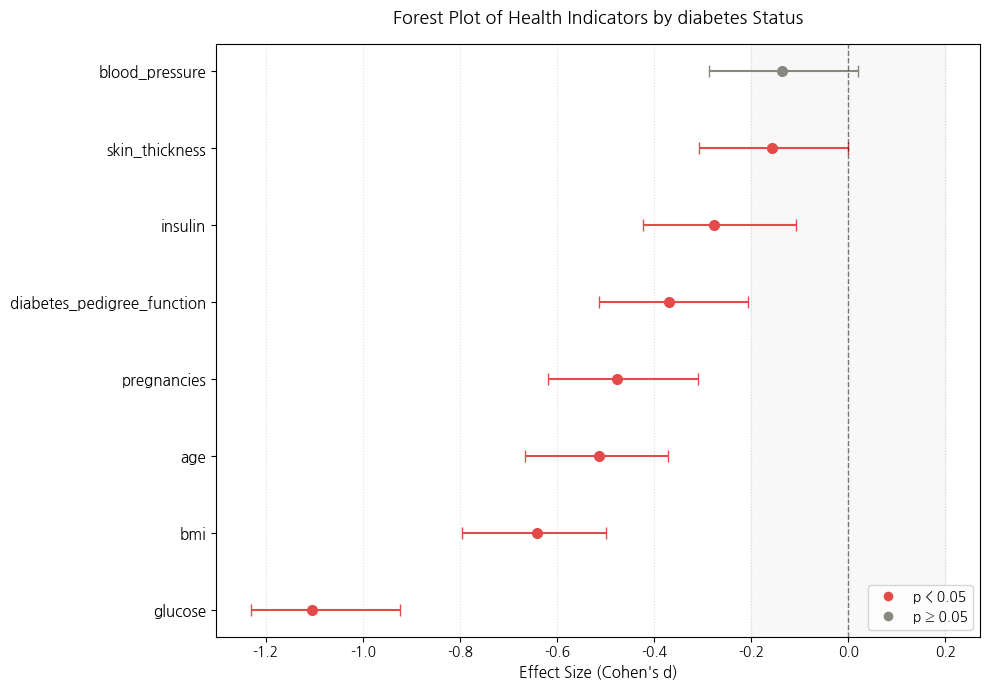

In [10]:
# ── Forest Plot (t-test 결과 시각화) ──────────────────────────
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind, t

plot_data = []
for col in num_cols:
    g0 = df[df['outcome'] == 0][col].dropna()
    g1 = df[df['outcome'] == 1][col].dropna()

    d = cohens_d(g0, g1)
    _, p = ttest_ind(g0, g1, nan_policy='omit')

    # 신뢰구간 계산
    se = np.sqrt(g0.var(ddof=1)/len(g0) + g1.var(ddof=1)/len(g1))
    margin = t.ppf(0.975, df=len(g0)+len(g1)-2) * se
    std_pool = (g0.std(ddof=1) + g1.std(ddof=1)) / 2
    lo_d = (g0.mean() - g1.mean() - margin) / std_pool
    hi_d = (g0.mean() - g1.mean() + margin) / std_pool

    plot_data.append({'변수': col, 'd': d, 'lo': lo_d, 'hi': hi_d, 'p': p})

df_plot = pd.DataFrame(plot_data).sort_values('d')
colors = ['#E24B4A' if row['p'] < 0.05 else '#888780' for _, row in df_plot.iterrows()]

fig, ax = plt.subplots(figsize=(10, 7))
for i, (_, row) in enumerate(df_plot.iterrows()):
    ax.errorbar(x=row['d'], y=i,
            xerr=[[abs(row['d'] - row['lo'])], [abs(row['hi'] - row['d'])]],
            fmt='o', color=colors[i], ecolor=colors[i],
            capsize=4, markersize=7, linewidth=1.5)

ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvspan(-0.2, 0.2, alpha=0.05, color='gray')
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot['변수'], fontsize=11)
ax.set_xlabel("Effect Size (Cohen's d)", fontsize=11)
ax.set_title("Forest Plot of Health Indicators by diabetes Status", fontsize=13, pad=15)
ax.grid(axis='x', linestyle=':', alpha=0.4)
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E24B4A', markersize=8, label='p < 0.05'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#888780', markersize=8, label='p ≥ 0.05'),
], loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()